In [44]:
# ------------------------------------------------------------
# STEP 1: LOAD DATA
# ------------------------------------------------------------

import pandas as pd
import numpy as np

url = "gs://agntworks-data-dev/sandbox/experiments/clean_flight_data_with_regime_v3.csv"

df = pd.read_csv(url, parse_dates=["dep_datetime"])

print("Shape:", df.shape)
df.head()

Shape: (10794, 12)


,Trip_Number,Trip_Legs_ID,dep_date,dep_datetime,Dep_Time_Actual_GMT,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime
0,157565,42366991KODR3217,2016-01-01,2016-01-01 23:37:00,23:37:00,WASHINGTON_DC_CLUSTER,OTHER_CLUSTER,44251.20,11954.115640,2.850000,4194.426540,NORMAL
1,157565,420331372FOSJ3517,2016-01-02,2016-01-02 18:00:00,18:00:00,OTHER_CLUSTER,MIAMI_CLUSTER,44251.20,6291.639810,1.500000,4194.426540,PEAK_MIXED
2,157565,420331372FOSJ4217,2016-01-02,2016-01-02 20:42:00,20:42:00,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,44251.20,26005.444550,6.200000,4194.426540,PEAK_MIXED
3,162215,42125996CASG317,2016-01-10,2016-01-10 14:56:00,14:56:00,BOSTON_CLUSTER,OTHER_CLUSTER,76864.32,22011.546392,4.166667,5282.771134,HIGH_YIELD
4,162215,423761209HARN017,2016-01-10,2016-01-10 21:10:00,21:10:00,OTHER_CLUSTER,SAN_JUAN_CLUSTER,76864.32,6251.279175,1.183333,5282.771134,HIGH_YIELD


In [45]:
# ------------------------------------------------------------
# CELL 2: CREATE CORRIDOR
# ------------------------------------------------------------

print("Checking required columns...")
print("Dep_cluster" in df.columns, "Arr_cluster" in df.columns)

# Build corridor
df["corridor"] = df["Dep_cluster"] + "→" + df["Arr_cluster"]

# Remove OTHER_CLUSTER noise
df = df[~df["corridor"].str.contains("OTHER_CLUSTER", na=False)]

# Remove same-origin-destination (repo noise)
df = df[df["Dep_cluster"] != df["Arr_cluster"]]

print("Rows after cleaning:", len(df))
print("Unique corridors:", df["corridor"].nunique())

df[["Dep_cluster", "Arr_cluster", "corridor"]].head()

Checking required columns...
True True
Rows after cleaning: 8606
Unique corridors: 521


,Dep_cluster,Arr_cluster,corridor
2,MIAMI_CLUSTER,SAN_FRANCISCO_CLUSTER,MIAMI_CLUSTER→SAN_FRANCISCO_CLUSTER
5,SAN_JUAN_CLUSTER,MIAMI_CLUSTER,SAN_JUAN_CLUSTER→MIAMI_CLUSTER
8,NEW_YORK_CLUSTER,BOSTON_CLUSTER,NEW_YORK_CLUSTER→BOSTON_CLUSTER
9,BOSTON_CLUSTER,SAN_JUAN_CLUSTER,BOSTON_CLUSTER→SAN_JUAN_CLUSTER
11,SAN_JUAN_CLUSTER,BOSTON_CLUSTER,SAN_JUAN_CLUSTER→BOSTON_CLUSTER


In [46]:
# ------------------------------------------------------------
# CELL 3: REQUIRED COLUMNS CHECK
# ------------------------------------------------------------

required_cols = [
    "corridor",
    "regime",
    "RevHr_clean",
    "Revenue_allocated"
]

missing = [c for c in required_cols if c not in df.columns]

print("Missing columns:", missing)

print("\nNulls:")
print(df[required_cols].isna().sum())

Missing columns: []

Nulls:
corridor             0
regime               0
RevHr_clean          0
Revenue_allocated    0
dtype: int64


In [47]:
print("Same-cluster rows remaining:",
      (df["Dep_cluster"] == df["Arr_cluster"]).sum())

Same-cluster rows remaining: 0


In [48]:
# ------------------------------------------------------------
# CELL 4: SAMPLE SIZE BY CORRIDOR × REGIME
# ------------------------------------------------------------

corridor_regime_counts = (
    df.groupby(["corridor", "regime"])
      .size()
      .reset_index(name="flights")
)

corridor_regime_counts = corridor_regime_counts.sort_values(
    "flights", ascending=False
)

corridor_regime_counts.head(20)

,corridor,regime,flights
790,MIAMI_CLUSTER→NEW_YORK_CLUSTER,NORMAL,184
922,NEW_YORK_CLUSTER→MIAMI_CLUSTER,NORMAL,142
725,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,NORMAL,101
1207,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,NORMAL,101
169,BOSTON_CLUSTER→NEW_YORK_CLUSTER,NORMAL,100
883,NEW_YORK_CLUSTER→BOSTON_CLUSTER,NORMAL,96
1219,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,77
891,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,NORMAL,73
946,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,NORMAL,70
291,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,66


In [49]:
# ------------------------------------------------------------
# CELL 5: DISTRIBUTION OF SAMPLE SIZE
# ------------------------------------------------------------

print("Flights per (corridor × regime):")
print(corridor_regime_counts["flights"].describe())

print("\nBucketed distribution:")
print(
    pd.cut(
        corridor_regime_counts["flights"],
        bins=[0, 5, 10, 20, 50, 100, 500]
    ).value_counts().sort_index()
)

Flights per (corridor × regime):
count    1436.000000
mean        5.993036
std        11.198368
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max       184.000000
Name: flights, dtype: float64

Bucketed distribution:
flights
(0, 5]        1047
(5, 10]        195
(10, 20]       113
(20, 50]        66
(50, 100]       11
(100, 500]       4
Name: count, dtype: int64


In [50]:
# ------------------------------------------------------------
# CELL 6: CORRIDOR DENSITY (HEAD OF DISTRIBUTION)
# ------------------------------------------------------------

corridor_total = (
    df.groupby("corridor")
      .agg(
          flights=("Trip_Legs_ID", "count"),
          total_revenue=("Revenue_allocated", "sum")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
)

corridor_total["total_revenue"] = corridor_total["total_revenue"].round(0)

corridor_total.head(20)

,corridor,flights,total_revenue
279,MIAMI_CLUSTER→NEW_YORK_CLUSTER,293,4539167.0
325,NEW_YORK_CLUSTER→MIAMI_CLUSTER,241,3732947.0
58,BOSTON_CLUSTER→NEW_YORK_CLUSTER,178,1130057.0
257,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,170,1364936.0
313,NEW_YORK_CLUSTER→BOSTON_CLUSTER,169,1037140.0
435,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,165,1230083.0
439,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,128,3864537.0
316,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,117,1338423.0
106,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,117,1085692.0
512,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,112,761451.0


In [51]:
# ------------------------------------------------------------
# CELL 6: CORRIDOR DENSITY (HEAD OF DISTRIBUTION)
# ------------------------------------------------------------

corridor_total = (
    df.groupby("corridor")
      .agg(
          flights=("Trip_Legs_ID", "count"),
          total_revenue=("Revenue_allocated", "sum")
      )
      .reset_index()
      .sort_values("flights", ascending=False)
)

corridor_total["total_revenue"] = corridor_total["total_revenue"].round(0)

corridor_total.head(20)

,corridor,flights,total_revenue
279,MIAMI_CLUSTER→NEW_YORK_CLUSTER,293,4539167.0
325,NEW_YORK_CLUSTER→MIAMI_CLUSTER,241,3732947.0
58,BOSTON_CLUSTER→NEW_YORK_CLUSTER,178,1130057.0
257,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,170,1364936.0
313,NEW_YORK_CLUSTER→BOSTON_CLUSTER,169,1037140.0
435,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,165,1230083.0
439,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,128,3864537.0
316,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,117,1338423.0
106,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,117,1085692.0
512,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,112,761451.0


In [52]:
# ------------------------------------------------------------
# CELL 7: FILTER TO CORE CORRIDORS
# ------------------------------------------------------------

MIN_CORRIDOR_FLIGHTS = 80  # based on your data distribution

core_corridors = corridor_total[
    corridor_total["flights"] >= MIN_CORRIDOR_FLIGHTS
]["corridor"]

df_core = df[df["corridor"].isin(core_corridors)].copy()

print("Core corridors:", len(core_corridors))
print("Rows retained:", len(df_core))


Core corridors: 15
Rows retained: 2174


In [53]:
# ------------------------------------------------------------
# CELL 8: SAMPLE SIZE (CORE CORRIDORS ONLY)
# ------------------------------------------------------------

core_counts = (
    df_core.groupby(["corridor", "regime"])
           .size()
           .reset_index(name="flights")
)

core_counts = core_counts.sort_values("flights", ascending=False)

core_counts.head(20)

,corridor,regime,flights
22,MIAMI_CLUSTER→NEW_YORK_CLUSTER,NORMAL,184
38,NEW_YORK_CLUSTER→MIAMI_CLUSTER,NORMAL,142
50,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,NORMAL,101
14,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,NORMAL,101
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,NORMAL,100
26,NEW_YORK_CLUSTER→BOSTON_CLUSTER,NORMAL,96
54,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,77
30,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,NORMAL,73
42,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,NORMAL,70
6,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,66


In [54]:
# ------------------------------------------------------------
# CELL 9: SAMPLE SIZE DISTRIBUTION (CORE)
# ------------------------------------------------------------

print("Flights per (corridor × regime):")
print(core_counts["flights"].describe())

print("\nBucketed distribution:")
print(
    pd.cut(
        core_counts["flights"],
        bins=[0, 5, 10, 20, 50, 100, 500]
    ).value_counts().sort_index()
)

Flights per (corridor × regime):
count     60.000000
mean      36.233333
std       35.308503
min        4.000000
25%       15.000000
50%       20.500000
75%       46.000000
max      184.000000
Name: flights, dtype: float64

Bucketed distribution:
flights
(0, 5]         2
(5, 10]        4
(10, 20]      24
(20, 50]      15
(50, 100]     11
(100, 500]     4
Name: count, dtype: int64


In [55]:
# ------------------------------------------------------------
# CELL 10: PIVOT COUNTS (CORE)
# ------------------------------------------------------------

pivot_core = core_counts.pivot_table(
    index="corridor",
    columns="regime",
    values="flights",
    aggfunc="first"
).reset_index()

pivot_core.head()

regime,corridor,HIGH_VOLUME,HIGH_YIELD,NORMAL,PEAK_MIXED
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,15,41,100,22
1,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,15,21,66,15
2,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,11,18,55,14
3,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,27,23,101,19
4,MIAMI_CLUSTER→BOSTON_CLUSTER,9,14,56,12


In [56]:
# ------------------------------------------------------------
# CELL 11: VOLUME BALANCE (CORE)
# ------------------------------------------------------------

pivot_core["flights_NORMAL"] = pivot_core.get("NORMAL", np.nan)
pivot_core["flights_HIGH_YIELD"] = pivot_core.get("HIGH_YIELD", np.nan)

pivot_core["volume_ratio"] = (
    pivot_core["flights_HIGH_YIELD"] /
    pivot_core["flights_NORMAL"]
)

pivot_core.replace([np.inf, -np.inf], np.nan, inplace=True)

pivot_core.sort_values("flights_NORMAL", ascending=False).head(15)

regime,corridor,HIGH_VOLUME,HIGH_YIELD,NORMAL,PEAK_MIXED,flights_NORMAL,flights_HIGH_YIELD,volume_ratio
5,MIAMI_CLUSTER→NEW_YORK_CLUSTER,37,32,184,40,184,32,0.173913
9,NEW_YORK_CLUSTER→MIAMI_CLUSTER,25,31,142,43,142,31,0.218310
3,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,27,23,101,19,101,23,0.227723
12,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,19,30,101,15,101,30,0.297030
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,15,41,100,22,100,41,0.410000
6,NEW_YORK_CLUSTER→BOSTON_CLUSTER,19,34,96,20,96,34,0.354167
13,SAN_FRANCISCO_CLUSTER→NEW_YORK_CLUSTER,11,24,77,16,77,24,0.311688
7,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,10,19,73,15,73,19,0.260274
10,NEW_YORK_CLUSTER→SAN_FRANCISCO_CLUSTER,4,21,70,15,70,21,0.300000
1,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,15,21,66,15,66,21,0.318182


In [57]:
# ------------------------------------------------------------
# CELL 12: BALANCE DISTRIBUTION (CORE)
# ------------------------------------------------------------

print("Volume ratio stats:")
print(pivot_core["volume_ratio"].describe())

print("\nBucketed:")
print(
    pd.cut(
        pivot_core["volume_ratio"],
        bins=[0, 0.2, 0.4, 0.6, 1, 2]
    ).value_counts().sort_index()
)

Volume ratio stats:
count    15.000000
mean      0.283284
std       0.061199
min       0.173913
25%       0.238861
50%       0.297030
75%       0.317821
max       0.410000
Name: volume_ratio, dtype: float64

Bucketed:
volume_ratio
(0.0, 0.2]     1
(0.2, 0.4]    13
(0.4, 0.6]     1
(0.6, 1.0]     0
(1.0, 2.0]     0
Name: count, dtype: int64


In [58]:
# ------------------------------------------------------------
# CELL 13: VARIABILITY (CORE)
# ------------------------------------------------------------

variability_core = (
    df_core.groupby(["corridor", "regime"])
           .agg(
               flights=("RevHr_clean", "count"),
               median_revhr=("RevHr_clean", "median"),
               std_revhr=("RevHr_clean", "std"),
               q25=("RevHr_clean", lambda x: x.quantile(0.25)),
               q75=("RevHr_clean", lambda x: x.quantile(0.75))
           )
           .reset_index()
)

variability_core["iqr"] = variability_core["q75"] - variability_core["q25"]

variability_core.head(20)

,corridor,regime,flights,median_revhr,std_revhr,q25,q75,iqr
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,15,6085.889174,3085.182398,4973.707918,6491.632143,1517.924225
1,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,41,6736.991440,4380.524211,5793.925984,8625.519149,2831.593165
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,NORMAL,100,6127.659574,6216.703281,5412.428525,7838.182179,2425.753653
3,BOSTON_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,22,6835.761000,2461.043532,6047.612026,8368.891366,2321.279340
4,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,15,6310.217500,2433.821172,5425.437443,7398.630435,1973.192991
5,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,21,5786.497674,4441.331317,5206.189041,6596.712281,1390.523240
6,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,66,5770.821435,2205.681702,4671.373630,7272.266547,2600.892918
7,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,15,5757.545563,2236.473746,5407.074450,7313.891304,1906.816854
8,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,11,6134.185304,842.542030,5863.255997,7232.758097,1369.502099
9,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,18,5175.262551,2079.853913,3964.711735,5752.205550,1787.493815


In [59]:
# ------------------------------------------------------------
# CELL 14: RELATIVE VARIABILITY (CORE)
# ------------------------------------------------------------

variability_core["cv"] = (
    variability_core["std_revhr"] /
    variability_core["median_revhr"]
)

variability_core["iqr_ratio"] = (
    variability_core["iqr"] /
    variability_core["median_revhr"]
)

variability_core.replace([np.inf, -np.inf], np.nan, inplace=True)

variability_core.head(20)

,corridor,regime,flights,median_revhr,std_revhr,q25,q75,iqr,cv,iqr_ratio
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,15,6085.889174,3085.182398,4973.707918,6491.632143,1517.924225,0.506940,0.249417
1,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,41,6736.991440,4380.524211,5793.925984,8625.519149,2831.593165,0.650220,0.420305
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,NORMAL,100,6127.659574,6216.703281,5412.428525,7838.182179,2425.753653,1.014531,0.395870
3,BOSTON_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,22,6835.761000,2461.043532,6047.612026,8368.891366,2321.279340,0.360025,0.339579
4,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,15,6310.217500,2433.821172,5425.437443,7398.630435,1973.192991,0.385695,0.312698
5,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,21,5786.497674,4441.331317,5206.189041,6596.712281,1390.523240,0.767534,0.240305
6,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,66,5770.821435,2205.681702,4671.373630,7272.266547,2600.892918,0.382213,0.450697
7,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,15,5757.545563,2236.473746,5407.074450,7313.891304,1906.816854,0.388442,0.331186
8,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,11,6134.185304,842.542030,5863.255997,7232.758097,1369.502099,0.137352,0.223257
9,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,18,5175.262551,2079.853913,3964.711735,5752.205550,1787.493815,0.401884,0.345392


In [60]:
# ------------------------------------------------------------
# CELL 13: PERCENTILE VIEW (BETTER THAN REGIME COMPARISON)
# ------------------------------------------------------------

percentiles = (
    df_core.groupby("corridor")
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p75=("RevHr_clean", lambda x: x.quantile(0.75)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

percentiles.head(20)

,corridor,p50,p75,p90,flights
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,6334.013041,8203.187573,10434.394177,178
1,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,5777.790000,7150.588073,9193.607310,117
2,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,5850.345869,6508.708287,7245.142562,98
3,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,7650.852101,10505.533959,13578.367468,170
4,MIAMI_CLUSTER→BOSTON_CLUSTER,5371.656299,6779.195980,8556.987578,91
5,MIAMI_CLUSTER→NEW_YORK_CLUSTER,6315.789474,7803.053571,8880.693248,293
6,NEW_YORK_CLUSTER→BOSTON_CLUSTER,6820.153333,8966.114634,13979.483691,169
7,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,6335.614286,8018.415238,10119.838815,117
8,NEW_YORK_CLUSTER→LOS_ANGELES_CLUSTER,5441.231040,6018.198024,6505.539146,90
9,NEW_YORK_CLUSTER→MIAMI_CLUSTER,6121.113738,7464.863529,8765.102128,241


In [61]:
# ------------------------------------------------------------
# CELL 14: TAIL PRICING POWER
# ------------------------------------------------------------

percentiles["lift_75"] = percentiles["p75"] / percentiles["p50"]
percentiles["lift_90"] = percentiles["p90"] / percentiles["p50"]

percentiles = percentiles.sort_values("lift_90", ascending=False)

percentiles.head(20)

,corridor,p50,p75,p90,flights,lift_75,lift_90
6,NEW_YORK_CLUSTER→BOSTON_CLUSTER,6820.153333,8966.114634,13979.483691,169,1.314650,2.049732
3,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,7650.852101,10505.533959,13578.367468,170,1.373119,1.774752
11,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,6491.068687,8598.846639,11313.113318,95,1.324720,1.742874
12,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,7746.766600,11102.884800,13089.613882,165,1.433228,1.689687
14,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,6559.998352,8322.820461,10814.162692,112,1.268723,1.648501
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,6334.013041,8203.187573,10434.394177,178,1.295101,1.647359
7,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,6335.614286,8018.415238,10119.838815,117,1.265610,1.597294
4,MIAMI_CLUSTER→BOSTON_CLUSTER,5371.656299,6779.195980,8556.987578,91,1.262031,1.592989
1,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,5777.790000,7150.588073,9193.607310,117,1.237599,1.591198
9,NEW_YORK_CLUSTER→MIAMI_CLUSTER,6121.113738,7464.863529,8765.102128,241,1.219527,1.431946


In [62]:
# ------------------------------------------------------------
# CELL 15: PERCENTILES BY CORRIDOR × REGIME
# ------------------------------------------------------------

pct_regime = (
    df_core.groupby(["corridor", "regime"])
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p75=("RevHr_clean", lambda x: x.quantile(0.75)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

pct_regime.head(20)

,corridor,regime,p50,p75,p90,flights
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,6085.889174,6491.632143,9200.232083,15
1,BOSTON_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,6736.991440,8625.519149,10017.401408,41
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,NORMAL,6127.659574,7838.182179,10418.750611,100
3,BOSTON_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,6835.761000,8368.891366,10517.081361,22
4,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,6310.217500,7398.630435,9669.491038,15
5,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,5786.497674,6596.712281,9063.188235,21
6,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,NORMAL,5770.821435,7272.266547,9102.268333,66
7,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,PEAK_MIXED,5757.545563,7313.891304,9328.146889,15
8,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_VOLUME,6134.185304,7232.758097,7569.370787,11
9,LOS_ANGELES_CLUSTER→NEW_YORK_CLUSTER,HIGH_YIELD,5175.262551,5752.205550,6372.778174,18


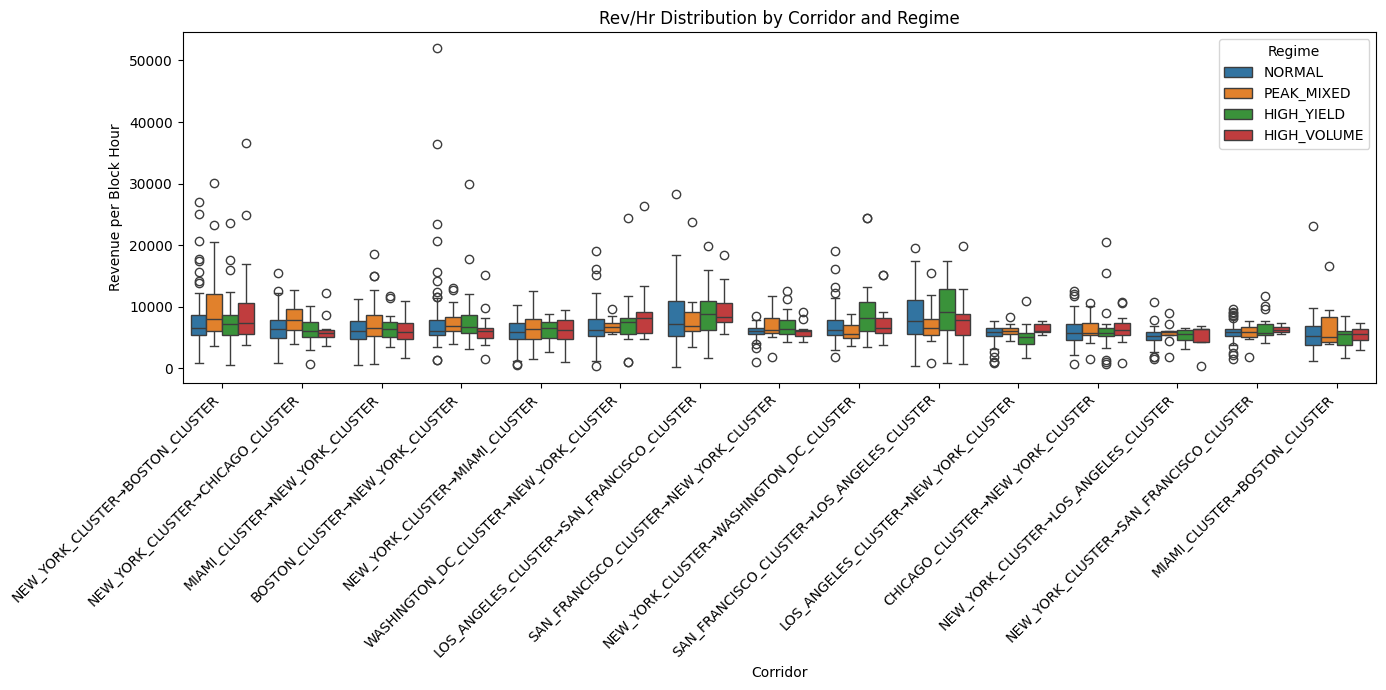

In [63]:
# ------------------------------------------------------------
# CELL 20: BOX PLOT (CORRIDOR × REGIME)
# ------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_core,
    x="corridor",
    y="RevHr_clean",
    hue="regime"
)

plt.xticks(rotation=45, ha="right")
plt.title("Rev/Hr Distribution by Corridor and Regime")
plt.ylabel("Revenue per Block Hour")
plt.xlabel("Corridor")

plt.legend(title="Regime")
plt.tight_layout()

plt.show()

In [64]:
# ------------------------------------------------------------
# CELL 23: CREATE DOW AND TOD FROM dep_datetime
# ------------------------------------------------------------

# Ensure datetime
df_core["dep_datetime"] = pd.to_datetime(df_core["dep_datetime"], errors="coerce")

# Day of week (0=Mon, 6=Sun)
df_core["dow"] = df_core["dep_datetime"].dt.dayofweek

# Optional: map to names (cleaner later)
dow_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}
df_core["dow_name"] = df_core["dow"].map(dow_map)

# Time of day buckets
def map_tod(hour):
    if pd.isna(hour):
        return np.nan
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df_core["hour"] = df_core["dep_datetime"].dt.hour
df_core["tod"] = df_core["hour"].apply(map_tod)

# Sanity check
df_core[["dep_datetime", "dow_name", "tod"]].head()

,dep_datetime,dow_name,tod
8,2016-02-01 12:40:00,Mon,Afternoon
24,2016-01-02 19:35:00,Sat,Evening
46,2016-01-03 19:00:00,Sun,Evening
53,2016-01-02 16:02:00,Sat,Afternoon
54,2016-01-03 16:02:00,Sun,Afternoon


In [65]:
dow_stats = (
    df_core.groupby(["corridor", "dow_name"])
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

dow_stats = dow_stats[dow_stats["flights"] >= 10].copy()
dow_stats["lift90"] = dow_stats["p90"] / dow_stats["p50"]

dow_stats.sort_values(["corridor", "lift90"], ascending=[True, False]).head(20)

,corridor,dow_name,p50,p90,flights,lift90
4,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,6209.416628,17563.584000,25,2.828540
1,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Mon,6872.946341,14209.517982,25,2.067457
3,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,6140.043243,11588.744828,21,1.887404
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sat,6161.701765,9701.622500,17,1.574504
6,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Wed,6266.460759,9698.564062,31,1.547694
5,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Tue,6713.066919,10326.734476,30,1.538304
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Fri,6011.952577,8341.454828,29,1.387478
10,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,Sun,5481.502743,10692.257353,15,1.950607
8,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,Mon,6426.247635,10937.103632,16,1.701942
13,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,Wed,5409.692079,9198.023636,15,1.700286


In [66]:
# ------------------------------------------------------------
# CELL 28: SHORTLIST CANDIDATES (DOW SIGNAL)
# ------------------------------------------------------------

# thresholds (tune if needed)
MIN_FLIGHTS = 15
MIN_LIFT = 1.6

shortlist = dow_stats[
    (dow_stats["flights"] >= MIN_FLIGHTS) &
    (dow_stats["lift90"] >= MIN_LIFT)
].copy()

# sort strongest first
shortlist = shortlist.sort_values("lift90", ascending=False)

shortlist.reset_index(drop=True, inplace=True)

shortlist

,corridor,dow_name,p50,p90,flights,lift90
0,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,7981.164796,24681.926574,23,3.092522
1,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,6500.626625,19016.801942,21,2.925380
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,6209.416628,17563.584000,25,2.828540
3,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,7828.302153,19190.597704,26,2.451438
4,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Tue,6472.077910,14278.315500,24,2.206141
5,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,7169.094876,15075.760813,22,2.102882
6,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Mon,6872.946341,14209.517982,25,2.067457
7,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Thu,7743.877419,15670.082927,21,2.023545
8,CHICAGO_CLUSTER→NEW_YORK_CLUSTER,Sun,5481.502743,10692.257353,15,1.950607
9,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,6140.043243,11588.744828,21,1.887404


In [67]:
# ------------------------------------------------------------
# CELL 29: LIMIT TO TOP N CANDIDATES
# ------------------------------------------------------------

TOP_N = 6

shortlist_top = shortlist.head(TOP_N).copy()

shortlist_top

,corridor,dow_name,p50,p90,flights,lift90
0,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,7981.164796,24681.926574,23,3.092522
1,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,6500.626625,19016.801942,21,2.925380
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,6209.416628,17563.584000,25,2.828540
3,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,7828.302153,19190.597704,26,2.451438
4,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Tue,6472.077910,14278.315500,24,2.206141
5,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,7169.094876,15075.760813,22,2.102882


In [68]:
# ------------------------------------------------------------
# CELL 30: FILTER RAW DATA FOR SHORTLIST
# ------------------------------------------------------------

df_focus = df_core.merge(
    shortlist_top[["corridor", "dow_name"]],
    on=["corridor", "dow_name"],
    how="inner"
)

print("Rows in focus set:", len(df_focus))
df_focus.head()

Rows in focus set: 141


,Trip_Number,Trip_Legs_ID,dep_date,dep_datetime,Dep_Time_Actual_GMT,Dep_cluster,Arr_cluster,Quote_Total_Cost,Revenue_allocated,Block_Hours,RevHr_clean,regime,corridor,dow,dow_name,hour,tod
0,162216,423961225KODR8017,2016-02-01,2016-02-01 12:40:00,12:40:00,NEW_YORK_CLUSTER,BOSTON_CLUSTER,80640.00,4564.528302,0.550000,8299.142367,NORMAL,NEW_YORK_CLUSTER→BOSTON_CLUSTER,0,Mon,12,Afternoon
1,170408,42374301PERR3517,2016-01-08,2016-01-08 22:50:00,22:50:00,NEW_YORK_CLUSTER,BOSTON_CLUSTER,61129.23,42560.867648,24.716667,1721.950141,NORMAL,NEW_YORK_CLUSTER→BOSTON_CLUSTER,4,Fri,22,Night
2,172972,42373878HARN3517,2016-01-07,2016-01-07 19:36:00,19:36:00,BOSTON_CLUSTER,NEW_YORK_CLUSTER,36003.44,4949.259946,0.850000,5822.658760,NORMAL,BOSTON_CLUSTER→NEW_YORK_CLUSTER,3,Thu,19,Evening
3,172977,42370246PERR017,2016-01-05,2016-01-05 16:05:00,16:05:00,NEW_YORK_CLUSTER,BOSTON_CLUSTER,41075.57,6474.443850,1.016667,6368.305426,NORMAL,NEW_YORK_CLUSTER→BOSTON_CLUSTER,1,Tue,16,Afternoon
4,173589,42371259PERR017,2016-01-04,2016-01-04 22:55:00,22:55:00,LOS_ANGELES_CLUSTER,SAN_FRANCISCO_CLUSTER,71786.57,5907.900947,0.883333,6688.189752,HIGH_VOLUME,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,0,Mon,22,Night


In [69]:
# ------------------------------------------------------------
# CELL 31: DECOMPOSE BY REGIME
# ------------------------------------------------------------

decomp = (
    df_focus.groupby(["corridor", "dow_name", "regime"])
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

# keep only meaningful buckets
decomp = decomp[decomp["flights"] >= 8].copy()

decomp["lift90"] = decomp["p90"] / decomp["p50"]

decomp.sort_values(
    ["corridor", "dow_name", "lift90"],
    ascending=[True, True, False]
).head(30)

,corridor,dow_name,regime,p50,p90,flights,lift90
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,NORMAL,6185.802831,35113.599909,12,5.676482
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,HIGH_VOLUME,5860.917105,7120.722500,8,1.214950
6,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,NORMAL,6301.948138,14636.754780,14,2.322576
11,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,PEAK_MIXED,8561.334545,24630.088869,9,2.876898
10,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,NORMAL,6528.878211,16796.277391,12,2.572613
14,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,NORMAL,7441.481250,10653.068186,15,1.431579
17,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Tue,HIGH_YIELD,6575.850394,15977.550000,11,2.429731
18,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Tue,NORMAL,6499.334292,9760.051156,10,1.501700
22,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,NORMAL,6142.064396,11128.441613,17,1.811841


In [70]:
# ------------------------------------------------------------
# CELL 34: BUILD ANCHOR DATASET
# ------------------------------------------------------------

# manually define anchors from your shortlist
anchors = decomp[
    (decomp["lift90"] >= 2.0) &
    (decomp["flights"] >= 10)
][["corridor", "dow_name", "regime"]].copy()

df_anchor = df_core.merge(
    anchors,
    on=["corridor", "dow_name", "regime"],
    how="inner"
)

print("Anchor rows:", len(df_anchor))

Anchor rows: 49


In [71]:
# ------------------------------------------------------------
# CELL 35: ADD TOD (CONTROLLED)
# ------------------------------------------------------------

tod_decomp = (
    df_anchor.groupby(["corridor", "dow_name", "regime", "tod"])
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

# density filter (important)
tod_decomp = tod_decomp[tod_decomp["flights"] >= 5].copy()

tod_decomp["lift90"] = tod_decomp["p90"] / tod_decomp["p50"]

tod_decomp.sort_values("lift90", ascending=False).head(20)

,corridor,dow_name,regime,tod,p50,p90,flights,lift90
1,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,NORMAL,Evening,6756.607934,41075.474001,8,6.079304
8,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,NORMAL,Evening,6528.878211,14750.636834,6,2.259291
4,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,NORMAL,Evening,5959.409341,13105.970480,5,2.199206
6,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,NORMAL,Night,6644.486936,10735.898270,5,1.615760


In [72]:
# ------------------------------------------------------------
# CELL 36: BEST TOD PER ANCHOR
# ------------------------------------------------------------

best_tod = (
    tod_decomp.sort_values("lift90", ascending=False)
              .groupby(["corridor", "dow_name", "regime"], as_index=False)
              .first()
)

best_tod[[
    "corridor",
    "dow_name",
    "regime",
    "tod",
    "flights",
    "p50",
    "p90",
    "lift90"
]].head(20)

,corridor,dow_name,regime,tod,flights,p50,p90,lift90
0,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Thu,NORMAL,Evening,8,6756.607934,41075.474001,6.079304
1,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Mon,NORMAL,Evening,5,5959.409341,13105.970480,2.199206
2,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Fri,NORMAL,Evening,6,6528.878211,14750.636834,2.259291


In [73]:
df_anchor[
    (df_anchor["corridor"] == "BOSTON_CLUSTER→NEW_YORK_CLUSTER") &
    (df_anchor["dow_name"] == "Thu") &
    (df_anchor["regime"] == "NORMAL")
]["RevHr_clean"].sort_values()

43     4730.045249
26     4909.212658
24     5034.172131
41     5413.601686
3      5571.449702
1      5822.658760
12     6548.946903
11     6964.268966
2      7459.514943
7     23476.640000
48    36406.595455
47    51969.523944
Name: RevHr_clean, dtype: float64

In [74]:
df_anchor[
    (df_anchor["corridor"] == "BOSTON_CLUSTER→NEW_YORK_CLUSTER") &
    (df_anchor["dow_name"] == "Thu") &
    (df_anchor["regime"] == "NORMAL")
].sort_values("RevHr_clean", ascending=False)[
    ["RevHr_clean", "dep_datetime", "tod"]
]

,RevHr_clean,dep_datetime,tod
47,51969.523944,2016-06-30 18:52:00,Evening
48,36406.595455,2016-06-30 20:55:00,Evening
7,23476.640000,2016-02-04 21:47:00,Evening
2,7459.514943,2016-03-17 23:38:00,Night
11,6964.268966,2016-02-04 19:40:00,Evening
12,6548.946903,2016-02-04 20:49:00,Evening
1,5822.658760,2016-01-07 19:36:00,Evening
3,5571.449702,2016-01-28 16:30:00,Afternoon
41,5413.601686,2016-06-09 21:54:00,Evening
24,5034.172131,2016-03-31 00:58:00,Night


In [75]:
# ------------------------------------------------------------
# CELL 37: STABLE LIFT (P75 / P50)
# ------------------------------------------------------------

stable = (
    df_core.groupby(["corridor", "dow_name", "tod"])
    .agg(
        p50=("RevHr_clean", lambda x: x.quantile(0.50)),
        p75=("RevHr_clean", lambda x: x.quantile(0.75)),
        p90=("RevHr_clean", lambda x: x.quantile(0.90)),
        flights=("RevHr_clean", "count")
    )
    .reset_index()
)

# density filter
stable = stable[stable["flights"] >= 8].copy()

# compute lifts
stable["lift75"] = stable["p75"] / stable["p50"]
stable["lift90"] = stable["p90"] / stable["p50"]

stable.sort_values("lift75", ascending=False).head(20)

,corridor,dow_name,tod,p50,p75,p90,flights,lift75,lift90
150,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,Night,8582.698496,24951.489796,28921.958057,9,2.907185,3.369798
285,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,Night,10424.168121,20375.010831,24449.637500,8,1.954593,2.345476
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,6510.712907,11640.422449,12095.513684,12,1.787888,1.857786
154,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Sun,Afternoon,5555.555556,9676.614286,10670.500533,9,1.741791,1.920690
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,5485.213535,9502.297857,14254.736822,10,1.732348,2.598757
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,6274.633016,10010.300345,11450.716345,12,1.595360,1.824922
334,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,6016.967100,9400.020321,10533.345314,8,1.562252,1.750607
111,MIAMI_CLUSTER→BOSTON_CLUSTER,Tue,Afternoon,4626.952347,7082.483931,7887.041187,8,1.530702,1.704587
158,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Thu,Evening,7536.611787,11522.664816,13643.422425,8,1.528892,1.810286
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,5646.322619,8360.241451,9987.611663,13,1.480652,1.768870


In [76]:
# ------------------------------------------------------------
# CELL 38: IDENTIFY TOGGLE CANDIDATES
# ------------------------------------------------------------

# thresholds (tune later)
MIN_FLIGHTS = 10
MIN_LIFT75 = 1.3   # real signal
MIN_LIFT90 = 1.8   # spike potential

toggles = stable[
    (stable["flights"] >= MIN_FLIGHTS) &
    (stable["lift75"] >= MIN_LIFT75)
].copy()

# classify strength
def classify(row):
    if row["lift75"] >= 1.5:
        return "STRONG_BASE"
    elif row["lift90"] >= 2.0:
        return "SPIKE_PRONE"
    else:
        return "MODERATE"

toggles["type"] = toggles.apply(classify, axis=1)

toggles.sort_values("lift75", ascending=False).head(20)

,corridor,dow_name,tod,p50,p75,p90,flights,lift75,lift90,type
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,6510.712907,11640.422449,12095.513684,12,1.787888,1.857786,STRONG_BASE
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,5485.213535,9502.297857,14254.736822,10,1.732348,2.598757,STRONG_BASE
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,6274.633016,10010.300345,11450.716345,12,1.595360,1.824922,STRONG_BASE
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,5646.322619,8360.241451,9987.611663,13,1.480652,1.768870,MODERATE
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,7585.049905,10881.966940,13171.891809,10,1.434660,1.736560,MODERATE
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,9343.515152,13358.318919,15309.983196,17,1.429689,1.638568,MODERATE
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,7190.188907,10159.933442,11986.422775,12,1.413027,1.667053,MODERATE
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,5720.787352,8049.642506,8638.915385,12,1.407086,1.510092,MODERATE
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,5171.489463,7186.620629,8640.511720,12,1.389662,1.670798,MODERATE
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,8199.141245,11272.362712,13066.410882,10,1.374822,1.593632,MODERATE


In [77]:
# ------------------------------------------------------------
# CELL 39: FINAL TOGGLE TABLE
# ------------------------------------------------------------

final_toggles = toggles[[
    "corridor",
    "dow_name",
    "tod",
    "flights",
    "p50",
    "p75",
    "p90",
    "lift75",
    "lift90",
    "type"
]].sort_values("lift75", ascending=False)

final_toggles.head(15)

,corridor,dow_name,tod,flights,p50,p75,p90,lift75,lift90,type
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,12095.513684,1.787888,1.857786,STRONG_BASE
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,14254.736822,1.732348,2.598757,STRONG_BASE
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,12,6274.633016,10010.300345,11450.716345,1.595360,1.824922,STRONG_BASE
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,13,5646.322619,8360.241451,9987.611663,1.480652,1.768870,MODERATE
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,10,7585.049905,10881.966940,13171.891809,1.434660,1.736560,MODERATE
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,17,9343.515152,13358.318919,15309.983196,1.429689,1.638568,MODERATE
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,12,7190.188907,10159.933442,11986.422775,1.413027,1.667053,MODERATE
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,12,5720.787352,8049.642506,8638.915385,1.407086,1.510092,MODERATE
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,12,5171.489463,7186.620629,8640.511720,1.389662,1.670798,MODERATE
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,10,8199.141245,11272.362712,13066.410882,1.374822,1.593632,MODERATE


In [78]:
# ------------------------------------------------------------
# CELL 40: DEFINE PRICING TIERS
# ------------------------------------------------------------

def assign_tier(row):
    if row["lift75"] >= 1.6:
        return "STRONG"
    elif row["lift75"] >= 1.4:
        return "MODERATE"
    else:
        return "WEAK"

final_toggles["tier"] = final_toggles.apply(assign_tier, axis=1)

# spike potential
final_toggles["spike_flag"] = final_toggles["lift90"] >= 2.0

final_toggles[[
    "corridor", "dow_name", "tod", "lift75", "lift90", "tier", "spike_flag"
]].head(15)

,corridor,dow_name,tod,lift75,lift90,tier,spike_flag
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,1.787888,1.857786,STRONG,False
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,1.732348,2.598757,STRONG,True
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,1.595360,1.824922,MODERATE,False
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,1.480652,1.768870,MODERATE,False
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,1.434660,1.736560,MODERATE,False
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,1.429689,1.638568,MODERATE,False
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,1.413027,1.667053,MODERATE,False
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,1.407086,1.510092,MODERATE,False
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,1.389662,1.670798,WEAK,False
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,1.374822,1.593632,WEAK,False


In [79]:
# ------------------------------------------------------------
# CELL 41: BUILD PRICE LADDERS (ARMS)
# ------------------------------------------------------------

def build_ladder(row):
    if row["tier"] == "STRONG":
        base = [0.00, 0.05, 0.10, 0.15]
        surge = [0.20] if row["spike_flag"] else []
    elif row["tier"] == "MODERATE":
        base = [0.00, 0.03, 0.06, 0.09]
        surge = [0.12] if row["spike_flag"] else []
    else:
        base = [0.00, 0.02, 0.04]
        surge = []

    return base + surge

final_toggles["price_ladder"] = final_toggles.apply(build_ladder, axis=1)

final_toggles[[
    "corridor", "dow_name", "tod", "tier", "price_ladder"
]].head(15)

,corridor,dow_name,tod,tier,price_ladder
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,STRONG,"[0.0, 0.05, 0.1, 0.15]"
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,STRONG,"[0.0, 0.05, 0.1, 0.15, 0.2]"
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,MODERATE,"[0.0, 0.03, 0.06, 0.09]"
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,WEAK,"[0.0, 0.02, 0.04]"
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,WEAK,"[0.0, 0.02, 0.04]"


In [80]:
# ------------------------------------------------------------
# CELL 42: INITIAL RECOMMENDED UPLIFT
# ------------------------------------------------------------

def initial_price(row):
    if row["tier"] == "STRONG":
        return 0.08
    elif row["tier"] == "MODERATE":
        return 0.05
    else:
        return 0.02

final_toggles["initial_uplift"] = final_toggles.apply(initial_price, axis=1)

final_toggles[[
    "corridor", "dow_name", "tod", "tier", "initial_uplift"
]].head(15)

,corridor,dow_name,tod,tier,initial_uplift
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,STRONG,0.08
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,STRONG,0.08
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,MODERATE,0.05
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,MODERATE,0.05
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,MODERATE,0.05
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,MODERATE,0.05
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,MODERATE,0.05
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,MODERATE,0.05
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,WEAK,0.02
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,WEAK,0.02


In [81]:
# ------------------------------------------------------------
# CELL 43: GUARDRAILS
# ------------------------------------------------------------

def max_uplift(row):
    if row["tier"] == "STRONG":
        return 0.20
    elif row["tier"] == "MODERATE":
        return 0.12
    else:
        return 0.06

final_toggles["max_uplift"] = final_toggles.apply(max_uplift, axis=1)

# floor (never discount yet)
final_toggles["min_uplift"] = 0.00

final_toggles[[
    "corridor", "tier", "min_uplift", "initial_uplift", "max_uplift"
]].head(15)

,corridor,tier,min_uplift,initial_uplift,max_uplift
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,STRONG,0.0,0.08,0.20
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,STRONG,0.0,0.08,0.20
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,MODERATE,0.0,0.05,0.12
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,MODERATE,0.0,0.05,0.12
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,MODERATE,0.0,0.05,0.12
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,MODERATE,0.0,0.05,0.12
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,MODERATE,0.0,0.05,0.12
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,MODERATE,0.0,0.05,0.12
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,WEAK,0.0,0.02,0.06
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,WEAK,0.0,0.02,0.06


In [82]:
# ------------------------------------------------------------
# CELL 44: FINAL PRICING CONFIG TABLE
# ------------------------------------------------------------

pricing_config = final_toggles[[
    "corridor",
    "dow_name",
    "tod",
    "flights",
    "p50",
    "p75",
    "p90",
    "lift75",
    "lift90",
    "tier",
    "spike_flag",
    "price_ladder",
    "initial_uplift",
    "min_uplift",
    "max_uplift"
]].copy()

pricing_config.sort_values("lift75", ascending=False).head(20)

,corridor,dow_name,tod,flights,p50,p75,p90,lift75,lift90,tier,spike_flag,price_ladder,initial_uplift,min_uplift,max_uplift
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,12095.513684,1.787888,1.857786,STRONG,False,"[0.0, 0.05, 0.1, 0.15]",0.08,0.0,0.20
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,14254.736822,1.732348,2.598757,STRONG,True,"[0.0, 0.05, 0.1, 0.15, 0.2]",0.08,0.0,0.20
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,12,6274.633016,10010.300345,11450.716345,1.595360,1.824922,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,13,5646.322619,8360.241451,9987.611663,1.480652,1.768870,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,10,7585.049905,10881.966940,13171.891809,1.434660,1.736560,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,17,9343.515152,13358.318919,15309.983196,1.429689,1.638568,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,12,7190.188907,10159.933442,11986.422775,1.413027,1.667053,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,12,5720.787352,8049.642506,8638.915385,1.407086,1.510092,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,12,5171.489463,7186.620629,8640.511720,1.389662,1.670798,WEAK,False,"[0.0, 0.02, 0.04]",0.02,0.0,0.06
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,10,8199.141245,11272.362712,13066.410882,1.374822,1.593632,WEAK,False,"[0.0, 0.02, 0.04]",0.02,0.0,0.06


In [83]:
# ------------------------------------------------------------
# CELL 45: SAMPLE BANDIT ARM (EPSILON GREEDY MOCK)
# ------------------------------------------------------------

import random

def choose_arm(row, epsilon=0.2):
    ladder = row["price_ladder"]
    
    if random.random() < epsilon:
        return random.choice(ladder)  # explore
    else:
        return row["initial_uplift"]  # exploit

pricing_config["chosen_uplift"] = pricing_config.apply(choose_arm, axis=1)

pricing_config[[
    "corridor", "dow_name", "tod", "price_ladder", "chosen_uplift"
]].head(10)

,corridor,dow_name,tod,price_ladder,chosen_uplift
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,"[0.0, 0.05, 0.1, 0.15]",0.10
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,"[0.0, 0.05, 0.1, 0.15, 0.2]",0.08
12,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,"[0.0, 0.03, 0.06, 0.09]",0.09
215,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,"[0.0, 0.03, 0.06, 0.09]",0.05
287,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,"[0.0, 0.03, 0.06, 0.09]",0.03
94,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,"[0.0, 0.03, 0.06, 0.09]",0.05
90,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,"[0.0, 0.03, 0.06, 0.09]",0.05
349,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,"[0.0, 0.03, 0.06, 0.09]",0.05
117,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,"[0.0, 0.02, 0.04]",0.02
72,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,"[0.0, 0.02, 0.04]",0.04


In [86]:
# ------------------------------------------------------------
# CELL 46 (FIXED): BUILD EXECUTIVE PACKET (NO REGIME MERGE)
# ------------------------------------------------------------

packet = pricing_config.copy()

# Add corridor-level density / scale
packet = packet.merge(
    corridor_total.rename(columns={
        "flights": "corridor_total_flights",
        "total_revenue": "corridor_total_revenue"
    }),
    on="corridor",
    how="left"
)

# Confidence scoring
def confidence_score(row):
    f = row["flights"]
    if f >= 15:
        return "HIGH"
    elif f >= 10:
        return "MEDIUM"
    else:
        return "LOW"

packet["confidence"] = packet.apply(confidence_score, axis=1)

# Clean ordering
packet = packet[[
    "corridor", "dow_name", "tod",
    "flights",
    "p50", "p75", "p90",
    "lift75", "lift90",
    "tier", "spike_flag",
    "price_ladder",
    "initial_uplift", "min_uplift", "max_uplift",
    "confidence",
    "corridor_total_flights", "corridor_total_revenue"
]]

packet.head(10)

,corridor,dow_name,tod,flights,p50,p75,p90,lift75,lift90,tier,spike_flag,price_ladder,initial_uplift,min_uplift,max_uplift,confidence,corridor_total_flights,corridor_total_revenue
0,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,12095.513684,1.787888,1.857786,STRONG,False,"[0.0, 0.05, 0.1, 0.15]",0.08,0.0,0.20,MEDIUM,165,1230083.0
1,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,14254.736822,1.732348,2.598757,STRONG,True,"[0.0, 0.05, 0.1, 0.15, 0.2]",0.08,0.0,0.20,MEDIUM,165,1230083.0
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,12,6274.633016,10010.300345,11450.716345,1.595360,1.824922,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,MEDIUM,178,1130057.0
3,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,13,5646.322619,8360.241451,9987.611663,1.480652,1.768870,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,MEDIUM,241,3732947.0
4,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,10,7585.049905,10881.966940,13171.891809,1.434660,1.736560,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,MEDIUM,165,1230083.0
5,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,17,9343.515152,13358.318919,15309.983196,1.429689,1.638568,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,HIGH,170,1364936.0
6,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,12,7190.188907,10159.933442,11986.422775,1.413027,1.667053,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,MEDIUM,170,1364936.0
7,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,12,5720.787352,8049.642506,8638.915385,1.407086,1.510092,MODERATE,False,"[0.0, 0.03, 0.06, 0.09]",0.05,0.0,0.12,MEDIUM,112,761451.0
8,MIAMI_CLUSTER→NEW_YORK_CLUSTER,Fri,Evening,12,5171.489463,7186.620629,8640.511720,1.389662,1.670798,WEAK,False,"[0.0, 0.02, 0.04]",0.02,0.0,0.06,MEDIUM,293,4539167.0
9,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Fri,Evening,10,8199.141245,11272.362712,13066.410882,1.374822,1.593632,WEAK,False,"[0.0, 0.02, 0.04]",0.02,0.0,0.06,MEDIUM,170,1364936.0


In [88]:
# ------------------------------------------------------------
# CELL 46A: DIAGNOSE MERGE COVERAGE
# ------------------------------------------------------------

# How many rows matched?
merged = packet.merge(
    pivot_core,
    on=["corridor", "dow_name"],
    how="left",
    indicator=True
)

print(merged["_merge"].value_counts())

# Show examples of misses
merged[merged["_merge"] == "left_only"][[
    "corridor", "dow_name", "tod"
]].head(10)

KeyError: 'dow_name'

In [131]:
# ------------------------------------------------------------
# CELL 47: FINAL TOGGLE CANDIDATES
# ------------------------------------------------------------

# Focus on meaningful signals only
top_packet = packet[
    (packet["flights"] >= 10) &
    (packet["lift75"] >= 1.35)
].copy()

# Sort by strength + density
top_packet = top_packet.sort_values(
    by=["lift75", "flights"],
    ascending=[False, False]
)

# Limit to top 8–10 for exec clarity
top_packet = top_packet.head(8)

top_packet[[
    "corridor", "dow_name", "tod",
    "flights", "p50", "p75", "p90",
    "lift75", "lift90",
    "tier", "initial_uplift", "max_uplift",
    "confidence"
]]

,corridor,dow_name,tod,flights,p50,p75,p90,lift75,lift90,tier,initial_uplift,max_uplift,confidence
0,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,12095.513684,1.787888,1.857786,STRONG,0.08,0.20,MEDIUM
1,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,14254.736822,1.732348,2.598757,STRONG,0.08,0.20,MEDIUM
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,12,6274.633016,10010.300345,11450.716345,1.595360,1.824922,MODERATE,0.05,0.12,MEDIUM
3,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,13,5646.322619,8360.241451,9987.611663,1.480652,1.768870,MODERATE,0.05,0.12,MEDIUM
4,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,10,7585.049905,10881.966940,13171.891809,1.434660,1.736560,MODERATE,0.05,0.12,MEDIUM
5,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Wed,Night,17,9343.515152,13358.318919,15309.983196,1.429689,1.638568,MODERATE,0.05,0.12,HIGH
6,LOS_ANGELES_CLUSTER→SAN_FRANCISCO_CLUSTER,Tue,Evening,12,7190.188907,10159.933442,11986.422775,1.413027,1.667053,MODERATE,0.05,0.12,MEDIUM
7,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Thu,Evening,12,5720.787352,8049.642506,8638.915385,1.407086,1.510092,MODERATE,0.05,0.12,MEDIUM


In [132]:
# ------------------------------------------------------------
# CELL 48: FORMAT DATA FOR LLM
# ------------------------------------------------------------

packet_for_llm = top_packet.copy()

# Round key metrics
round_cols = [
    "p50", "p75", "p90",
    "lift75", "lift90"
]

for col in round_cols:
    packet_for_llm[col] = packet_for_llm[col].round(2)

# Convert ladders to readable %
def format_ladder(lst):
    return [f"{int(x*100)}%" for x in lst]

packet_for_llm["price_ladder"] = packet_for_llm["price_ladder"].apply(format_ladder)

# Convert uplifts to %
packet_for_llm["initial_uplift"] = (packet_for_llm["initial_uplift"] * 100).astype(int)
packet_for_llm["max_uplift"] = (packet_for_llm["max_uplift"] * 100).astype(int)

packet_for_llm.head()

,corridor,dow_name,tod,flights,p50,p75,p90,lift75,lift90,tier,spike_flag,price_ladder,initial_uplift,min_uplift,max_uplift,confidence,corridor_total_flights,corridor_total_revenue
0,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.71,11640.42,12095.51,1.79,1.86,STRONG,False,"[0%, 5%, 10%, 15%]",8,0.0,20,MEDIUM,165,1230083.0
1,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.21,9502.30,14254.74,1.73,2.60,STRONG,True,"[0%, 5%, 10%, 15%, 20%]",8,0.0,20,MEDIUM,165,1230083.0
2,BOSTON_CLUSTER→NEW_YORK_CLUSTER,Sun,Evening,12,6274.63,10010.30,11450.72,1.60,1.82,MODERATE,False,"[0%, 3%, 6%, 9%]",5,0.0,12,MEDIUM,178,1130057.0
3,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Mon,Afternoon,13,5646.32,8360.24,9987.61,1.48,1.77,MODERATE,False,"[0%, 3%, 6%, 9%]",5,0.0,12,MEDIUM,241,3732947.0
4,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Fri,Evening,10,7585.05,10881.97,13171.89,1.43,1.74,MODERATE,False,"[0%, 3%, 6%, 9%]",5,0.0,12,MEDIUM,165,1230083.0


In [133]:
# ------------------------------------------------------------
# CELL 49: JSON PAYLOAD
# ------------------------------------------------------------

import json

packet_json = packet_for_llm.to_dict(orient="records")

print(json.dumps(packet_json, indent=2))

[
  {
    "corridor": "SAN_FRANCISCO_CLUSTER\u2192LOS_ANGELES_CLUSTER",
    "dow_name": "Wed",
    "tod": "Night",
    "flights": 12,
    "p50": 6510.71,
    "p75": 11640.42,
    "p90": 12095.51,
    "lift75": 1.79,
    "lift90": 1.86,
    "tier": "STRONG",
    "spike_flag": false,
    "price_ladder": [
      "0%",
      "5%",
      "10%",
      "15%"
    ],
    "initial_uplift": 8,
    "min_uplift": 0.0,
    "max_uplift": 20,
    "confidence": "MEDIUM",
    "corridor_total_flights": 165,
    "corridor_total_revenue": 1230083.0
  },
  {
    "corridor": "SAN_FRANCISCO_CLUSTER\u2192LOS_ANGELES_CLUSTER",
    "dow_name": "Mon",
    "tod": "Evening",
    "flights": 10,
    "p50": 5485.21,
    "p75": 9502.3,
    "p90": 14254.74,
    "lift75": 1.73,
    "lift90": 2.6,
    "tier": "STRONG",
    "spike_flag": true,
    "price_ladder": [
      "0%",
      "5%",
      "10%",
      "15%",
      "20%"
    ],
    "initial_uplift": 8,
    "min_uplift": 0.0,
    "max_uplift": 20,
    "confidence": "ME

In [134]:
system_prompt = """
You are a senior airline revenue management strategist and former McKinsey engagement manager.

Your task is to produce a C-level pricing toggle recommendation packet based ONLY on the provided dataset.

This document will be scrutinized by senior executives. Your output must be:
- highly structured
- numerically grounded
- conservative in claims
- explicit in limitations
- free of unsupported assumptions

------------------------------------------------------------
STRICT RULES
------------------------------------------------------------

1. Use ONLY the provided data. Do NOT invent facts or context.
2. Do NOT assume elasticity or customer willingness-to-pay.
3. Do NOT equate historical price spread with safe price increase.
4. Do NOT claim signals are "structural". Use ONLY:
   - "Repeatable (low spike dispersion)"
   - "Mixed (repeatable + spike-driven)"
   - "Spike-driven"
5. Explicitly call out small sample sizes (10–17 flights) as a PRIMARY limitation.
6. Assume this is historical data; acknowledge that market conditions may differ today.
7. All recommendations must be framed as:
   → bounded experiments, not optimal pricing decisions

------------------------------------------------------------
CORE ANALYTICAL LOGIC
------------------------------------------------------------

- p50 = baseline price
- p75 = repeatable premium zone (used for base pricing decisions)
- p90 = spike / tail zone (used ONLY for surge logic)

- lift75 = strength of repeatable premium
- lift90 = spike potential

Interpretation rules:
- If p75 ≈ p90 → likely repeatable pricing behavior
- If p90 >> p75 → spike-driven or event-driven pricing
- p75 informs base uplift; p90 informs surge ceiling

------------------------------------------------------------
CRITICAL BUSINESS FRAMING (MANDATORY)
------------------------------------------------------------

For each toggle, you MUST include:

1. Corridor importance:
   - reference total flights in that corridor
   - estimate % of total dataset traffic (even if approximate)
   - indicate relative importance (e.g., "top-tier corridor", "mid-tier corridor")

2. Impact sizing (directional):
   - Estimated incremental revenue =
     flights × p50 × initial uplift

   - Label clearly as:
     “Directional estimate for sizing only; assumes no demand response”

   - Clarify:
     “Per cycle represents one full observed set of flights; annual impact depends on frequency.”

3. Conservative pricing rationale:
   - Explicitly explain why uplift is limited to ~5–8%
   - Tie to:
     • lack of elasticity data
     • small samples
     • avoiding conversion shock

------------------------------------------------------------
REQUIRED OUTPUT FORMAT
------------------------------------------------------------

TITLE:
C-Level Pricing Toggle Recommendation Packet

------------------------------------------------------------
SECTION 1: EXECUTIVE SUMMARY
------------------------------------------------------------

5–8 bullets covering:

- Where pricing power exists (corridors + timing)
- Strong vs moderate opportunities
- Explicit statement:
  → findings are directional, not definitive
- Primary limitation:
  → small sample sizes
- Critical caveat:
  → no elasticity data
- Explicit positioning:
  → bounded pricing experiments

MANDATORY ADDITIONS:
- Rollout prioritization (top 2–3 toggles)
- Any cross-corridor symmetry insights (e.g., SFO↔LAX both directions)

------------------------------------------------------------
SECTION 2: HOW TO READ THIS ANALYSIS
------------------------------------------------------------

Explain clearly:
- p50 / p75 / p90
- why p75 drives base pricing decisions
- why p90 is NOT used for base pricing

------------------------------------------------------------
SECTION 3: RECOMMENDED TOGGLE TABLE
------------------------------------------------------------

Columns:

- Corridor
- Day
- Time of Day
- Flights
- p50 / p75 / p90
- lift75 / lift90
- Tier
- Confidence
- Recommended Base Uplift (%)
- Max Uplift (%)
- Signal Type:
  • Repeatable (low spike dispersion)
  • Mixed (repeatable + spike-driven)
  • Spike-driven

------------------------------------------------------------
SECTION 4: ESTIMATED IMPACT (DIRECTIONAL)
------------------------------------------------------------

For each toggle:

- Show:
  Estimated uplift = flights × p50 × uplift%

- Include:
  “Per cycle” explanation

- Include disclaimer:
  “Directional only; does not account for demand response”

------------------------------------------------------------
SECTION 5: DETAILED LOGIC (PER TOGGLE)
------------------------------------------------------------

For EACH toggle:

- Why selected
- What the math shows (p50 vs p75 vs p90)
- Signal type classification
- Corridor importance (% + qualitative tier)
- Estimated revenue impact (directional)
- Why uplift level is conservative

- Explicit risks:
  • small sample size
  • possible event contamination
  • lack of elasticity data

- For MIXED signals (MANDATORY):
  Include:
  “Mixed signals carry higher risk as repeatable premium may be overstated by embedded event-driven pricing.”

------------------------------------------------------------
SECTION 6: OPERATING MODEL
------------------------------------------------------------

Explain:

- min_uplift → floor (typically 0%)
- initial_uplift → starting test point
- max_uplift → hard guardrail

- price_ladder:
  → discrete steps for experimentation

Execution flow:

Phase 1:
→ initial uplift vs control

Phase 2:
→ evaluate performance

Phase 3:
→ move up/down ladder

Bandit logic:
→ explore vs exploit across ladder

MANDATORY:
Include kill condition:

“If uplift results in material degradation in conversion or net revenue vs control, revert to a lower ladder step or deactivate the toggle.”

------------------------------------------------------------
SECTION 7: RISKS AND GUARDRAILS
------------------------------------------------------------

Must include clearly:

1. Small sample sizes (primary limitation)
2. Event contamination risk
3. Lack of elasticity / conversion data (critical)
4. Historical data may not reflect current conditions
5. Need for phased rollout

Tone: direct and prominent, not buried.

------------------------------------------------------------
STYLE REQUIREMENTS
------------------------------------------------------------

- Executive tone (CEO / CCO ready)
- McKinsey-style structure
- Crisp bullets
- No fluff
- No marketing language
- No exaggeration

------------------------------------------------------------
FINAL POSITIONING (CRITICAL)
------------------------------------------------------------

The document MUST clearly communicate:

→ “We are identifying where pricing power appears to exist”
→ “We are NOT claiming optimal pricing”
→ “We are recommending controlled, bounded experiments”
"""

In [ ]:
# ------------------------------------------------------------
# CELL 51: RUN GEMINI
# ------------------------------------------------------------

from google import genai
from google.genai import types

client = genai.Client(vertexai=True, project="agntworks-dev", location="us-central1")

response = client.models.generate_content(
    model="gemini-2.5-pro",
    contents=[
        types.Content(
            role="user",
            parts=[types.Part(text=system_prompt + "\n\n" + user_prompt)]
        )
    ]
)

print(response.text)

In [ ]:
#HOW TO TEST THE TOGGLE EXPERIMENTS

In [ ]:
# SAMPLE ONLY — hardcode one toggle for tracking

TOGGLE = {
    "corridor": "SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER",
    "dow": "Wed",
    "tod": "Night"
}

# Define time windows
# Pre = baseline period (before uplift)
# Post = after uplift is applied

PRE_START = "2016-01-01"
PRE_END   = "2016-03-01"

POST_START = "2016-03-02"
POST_END   = "2016-05-01"

print("Tracking toggle:", TOGGLE)

In [ ]:
# Target = flights affected by the toggle

df_target = df[
    (df["corridor"] == TOGGLE["corridor"]) &
    (df["dow_name"] == TOGGLE["dow"]) &
    (df["tod"] == TOGGLE["tod"])
].copy()

print("Target flights:", len(df_target))

In [ ]:
# Control = same corridor but NOT the exact segment
# This removes broad demand trends

df_control = df[
    (df["corridor"] == TOGGLE["corridor"]) &
    ~(
        (df["dow_name"] == TOGGLE["dow"]) &
        (df["tod"] == TOGGLE["tod"])
    )
].copy()

print("Control flights:", len(df_control))

In [ ]:
# Convert datetime if needed
df_target["dep_datetime"] = pd.to_datetime(df_target["dep_datetime"])
df_control["dep_datetime"] = pd.to_datetime(df_control["dep_datetime"])

# Split periods
target_pre = df_target[
    (df_target["dep_datetime"] >= PRE_START) &
    (df_target["dep_datetime"] <= PRE_END)
]

target_post = df_target[
    (df_target["dep_datetime"] >= POST_START) &
    (df_target["dep_datetime"] <= POST_END)
]

control_pre = df_control[
    (df_control["dep_datetime"] >= PRE_START) &
    (df_control["dep_datetime"] <= PRE_END)
]

control_post = df_control[
    (df_control["dep_datetime"] >= POST_START) &
    (df_control["dep_datetime"] <= POST_END)
]

print("Target PRE:", len(target_pre), "POST:", len(target_post))
print("Control PRE:", len(control_pre), "POST:", len(control_post))

In [ ]:
# We measure:
# - revenue per flight (primary KPI)
# - NOT raw revenue (biased by volume)
# - NOT p90 (too noisy)

def summarize(df_slice):
    return {
        "flights": len(df_slice),
        "rev_per_flight": df_slice["Revenue_allocated"].sum() / max(len(df_slice), 1),
        "p50": df_slice["RevHr_clean"].median()
    }

target_pre_stats = summarize(target_pre)
target_post_stats = summarize(target_post)

control_pre_stats = summarize(control_pre)
control_post_stats = summarize(control_post)

print("Target PRE:", target_pre_stats)
print("Target POST:", target_post_stats)
print("Control PRE:", control_pre_stats)
print("Control POST:", control_post_stats)

In [ ]:
# CRITICAL IDEA:
# We compare target vs control to remove market movement

baseline_index = (
    target_pre_stats["rev_per_flight"] /
    control_pre_stats["rev_per_flight"]
)

post_index = (
    target_post_stats["rev_per_flight"] /
    control_post_stats["rev_per_flight"]
)

print("Baseline index:", baseline_index)
print("Post index:", post_index)

In [ ]:
# CRITICAL IDEA:
# We compare target vs control to remove market movement

baseline_index = (
    target_pre_stats["rev_per_flight"] /
    control_pre_stats["rev_per_flight"]
)

post_index = (
    target_post_stats["rev_per_flight"] /
    control_post_stats["rev_per_flight"]
)

print("Baseline index:", baseline_index)
print("Post index:", post_index)

In [ ]:
# This is the ONLY number that matters

uplift = (post_index / baseline_index) - 1

print("Indexed uplift (%):", round(uplift * 100, 2))

In [ ]:
# Naive uplift (WRONG way — for illustration)

naive = (
    target_post_stats["rev_per_flight"] /
    target_pre_stats["rev_per_flight"]
) - 1

print("Naive uplift (%):", round(naive * 100, 2))
print("Indexed uplift (%):", round(uplift * 100, 2))

In [ ]:
# Simple rules — tune later

MIN_FLIGHTS = 8  # minimum data to trust signal

if target_post_stats["flights"] < MIN_FLIGHTS:
    decision = "HOLD — insufficient data"

elif uplift > 0.03:
    decision = "MOVE UP ladder (increase price)"

elif uplift < -0.02:
    decision = "MOVE DOWN / KILL toggle"

else:
    decision = "HOLD — inconclusive"

print("Decision:", decision)

In [ ]:
# You should log every experiment iteration

result = {
    "corridor": TOGGLE["corridor"],
    "dow": TOGGLE["dow"],
    "tod": TOGGLE["tod"],
    "uplift_tested": 0.05,  # example: 5%
    "flights_post": target_post_stats["flights"],
    "rev_per_flight_post": target_post_stats["rev_per_flight"],
    "baseline_index": baseline_index,
    "post_index": post_index,
    "indexed_uplift": uplift,
    "decision": decision
}

import pandas as pd

experiment_log = pd.DataFrame([result])
experiment_log

In [ ]:
# ------------------------------------------------------------
# EXPERIMENT TRACKING FRAMEWORK — SUMMARY (STEPS 1–10)
# SAMPLE ONLY — DOCUMENTATION CELL FOR NOTEBOOK
# ------------------------------------------------------------

"""
This notebook implements a sequential pricing experiment framework
(no A/B testing). The goal is to measure whether a pricing toggle
creates TRUE uplift by isolating its effect from overall market movement.

Core principle:
We measure RELATIVE (indexed) performance vs a control — not raw before/after.

------------------------------------------------------------
STEP 1: DEFINE TOGGLE + TIME WINDOWS
------------------------------------------------------------
- Specify the segment (corridor × DOW × TOD)
- Define PRE (baseline) and POST (after uplift)

WHY:
Ensures we are measuring a clearly scoped intervention and clean comparison periods.

------------------------------------------------------------
STEP 2: ISOLATE TARGET SEGMENT
------------------------------------------------------------
- Filter data to only flights matching the toggle

WHY:
This is the TREATED group where pricing changed.

------------------------------------------------------------
STEP 3: DEFINE CONTROL GROUP
------------------------------------------------------------
- Same corridor, but different DOW/TOD (i.e., not treated segment)

WHY:
Acts as a proxy for overall market movement (demand, seasonality, noise).
This replaces A/B testing.

------------------------------------------------------------
STEP 4: SPLIT INTO PRE vs POST
------------------------------------------------------------
- Apply time filters to both target and control

WHY:
Creates a before/after structure aligned across both groups.

------------------------------------------------------------
STEP 5: COMPUTE CORE METRICS
------------------------------------------------------------
For each slice (target/control × pre/post), compute:
- Flights (sample size)
- Revenue per flight (PRIMARY KPI)
- Median RevHr (supporting)

WHY:
Revenue per flight isolates pricing effect (not volume-driven).
Median helps validate stability vs outliers.

------------------------------------------------------------
STEP 6: BUILD BASELINE INDEX
------------------------------------------------------------
baseline_index = target_pre / control_pre

WHY:
Establishes how the segment performed relative to the market BEFORE intervention.

------------------------------------------------------------
STEP 7: BUILD POST INDEX
------------------------------------------------------------
post_index = target_post / control_post

WHY:
Measures relative performance AFTER pricing change.

------------------------------------------------------------
STEP 8: COMPUTE TRUE UPLIFT
------------------------------------------------------------
uplift = (post_index / baseline_index) - 1

WHY:
This isolates pricing impact by removing market-wide effects.
This is the SINGLE most important metric.

------------------------------------------------------------
STEP 9: COMPARE VS NAIVE APPROACH
------------------------------------------------------------
naive = target_post / target_pre - 1

WHY:
Demonstrates why raw before/after is misleading.
Indexed uplift is the correct signal.

------------------------------------------------------------
STEP 10: DECISION LOGIC (SEQUENTIAL BANDIT)
------------------------------------------------------------
Based on uplift and sample size:

- If uplift > threshold → move UP ladder (increase price)
- If uplift ~ neutral → HOLD
- If uplift < negative threshold → move DOWN / KILL

WHY:
Implements controlled, stepwise optimization without A/B testing.

------------------------------------------------------------
FINAL TAKEAWAY
------------------------------------------------------------
We are NOT measuring:
- Raw revenue increase
- Absolute price levels

We ARE measuring:
"Did this segment outperform its natural market baseline after pricing change?"

This enables:
- Directional causal inference
- Safe sequential optimization
- Production-ready RM experimentation without A/B infra
"""

In [140]:
# ------------------------------------------------------------
# BUILD AGGREGATED DATASET FOR TOGGLE LOGIC
# ------------------------------------------------------------

import numpy as np

# Use df_core (already cleaned and enriched)
df_base = df_core.copy()

# Drop garbage rows
df_base = df_base[
    (df_base['RevHr_clean'].notna()) &
    (df_base['RevHr_clean'] > 0)
].copy()

# ------------------------------------------------------------
# GROUP + AGG
# ------------------------------------------------------------
df_agg = (
    df_base
    .groupby(['corridor', 'dow_name', 'tod'])
    .agg(
        flights=('RevHr_clean', 'count'),
        p50=('RevHr_clean', 'median'),
        p75=('RevHr_clean', lambda x: np.percentile(x, 75)),
        mean_revhr=('RevHr_clean', 'mean')
    )
    .reset_index()
)

# ------------------------------------------------------------
# DERIVED METRICS
# ------------------------------------------------------------
df_agg['lift75'] = df_agg['p75'] / df_agg['p50']

# Optional: remove unstable rows
df_agg = df_agg[df_agg['flights'] >= 5]

# ------------------------------------------------------------
# SORT FOR VISIBILITY
# ------------------------------------------------------------
df_agg = df_agg.sort_values(['lift75', 'flights'], ascending=[False, False])

print("df_agg shape:", df_agg.shape)
display(df_agg.head(10))

df_agg shape: (197, 8)


,corridor,dow_name,tod,flights,p50,p75,mean_revhr,lift75
150,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,Night,9,8582.698496,24951.489796,14536.318747,2.907185
285,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,Night,8,10424.168121,20375.010831,13197.455706,1.954593
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,8118.829458,1.787888
154,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Sun,Afternoon,9,5555.555556,9676.614286,6403.263779,1.741791
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,7836.816979,1.732348
161,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Tue,Evening,6,4950.236835,8546.211276,7033.511769,1.726425
169,NEW_YORK_CLUSTER→CHICAGO_CLUSTER,Fri,Evening,7,5944.700461,9865.269094,7455.712173,1.659507
356,WASHINGTON_DC_CLUSTER→NEW_YORK_CLUSTER,Wed,Evening,6,6290.882526,10254.658933,9071.695074,1.630083
228,NEW_YORK_CLUSTER→MIAMI_CLUSTER,Thu,Night,5,4094.390164,6623.345000,4123.648023,1.617663
151,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Sat,Afternoon,5,6001.356037,9606.150000,7659.740078,1.600663


In [141]:
df_agg.describe()

,flights,p50,p75,mean_revhr,lift75
count,197.000000,197.000000,197.000000,197.000000,197.000000
mean,9.131980,6517.199527,8111.948609,6925.267897,1.239579
std,4.971638,1333.854673,2441.795418,1695.248481,0.208261
min,5.000000,4094.390164,4908.859755,4123.648023,1.001658
25%,6.000000,5608.150551,6573.550421,5832.113902,1.105032
50%,8.000000,6175.786919,7592.811912,6602.924700,1.192434
75%,11.000000,7169.094876,9063.188235,7632.164881,1.320875
max,39.000000,12792.349367,24951.489796,14536.318747,2.907185


In [142]:
df_agg.head()

,corridor,dow_name,tod,flights,p50,p75,mean_revhr,lift75
150,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Mon,Night,9,8582.698496,24951.489796,14536.318747,2.907185
285,NEW_YORK_CLUSTER→WASHINGTON_DC_CLUSTER,Wed,Night,8,10424.168121,20375.010831,13197.455706,1.954593
308,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Wed,Night,12,6510.712907,11640.422449,8118.829458,1.787888
154,NEW_YORK_CLUSTER→BOSTON_CLUSTER,Sun,Afternoon,9,5555.555556,9676.614286,6403.263779,1.741791
291,SAN_FRANCISCO_CLUSTER→LOS_ANGELES_CLUSTER,Mon,Evening,10,5485.213535,9502.297857,7836.816979,1.732348


In [143]:
df_agg = df_agg[df_agg['lift75'] <= 2.2]

In [144]:
df_agg = df_agg[df_agg['flights'] >= 8]

In [152]:
# ------------------------------------------------------------
# BUILD + EXPORT CANDIDATES → GCS (CLEAN)
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# -----------------------------
# FILTER (clean signal)
# -----------------------------
df_exp = df_agg.copy()

df_exp = df_exp[
    (df_exp['lift75'] > 1.2) &
    (df_exp['lift75'] <= 2.2) &
    (df_exp['flights'] >= 8)
].copy()

# -----------------------------
# SCORE
# -----------------------------
df_exp['score'] = df_exp['lift75'] * np.log1p(df_exp['flights'])
df_exp = df_exp.sort_values('score', ascending=False)

# -----------------------------
# BUILD CANDIDATES
# -----------------------------
candidates = []

for idx, row in df_exp.head(30).reset_index(drop=True).iterrows():

    lift = float(row['lift75'])
    flights = int(row['flights'])
    p50 = float(row['p50'])

    # Pricing recommendation
    rec_pct = min(int((lift - 1) * 15), 10)
    rec_pct = max(rec_pct, 3)

    # Impact (directional)
    est_impact = int(p50 * 0.05 * flights)

    # Confidence
    if flights >= 12:
        confidence = "High"
    elif flights >= 9:
        confidence = "Medium"
    else:
        confidence = "Low"

    candidates.append({
        "id": idx + 1,  # safer than using df index
        "route": row['corridor'].replace("→", " → "),
        "aircraft": "SMID",
        "window": f"{row['dow_name']} {row['tod']}",
        "type": "Premium",
        "recommendation": f"+{rec_pct}% premium",
        "expected_impact": est_impact,
        "confidence": confidence,
        "risk": "Low",
        "rationale": f"lift75={round(lift,2)}, sample={flights}, p50=${int(p50)}"
    })

# -----------------------------
# ADD IMBALANCE (MVP)
# -----------------------------
candidates.append({
    "id": 9991,
    "route": "NORTHEAST → SOUTH FLORIDA",
    "aircraft": "CL30",
    "window": "Next 5 days",
    "type": "Imbalance",
    "recommendation": "-4% incentive",
    "expected_impact": 18000,
    "confidence": "Medium",
    "risk": "Medium",
    "rationale": "Regional deficit building"
})

# -----------------------------
# EXPORT DIRECTLY TO GCS
# -----------------------------
out = pd.DataFrame(candidates)

gcs_path = "gs://agntworks-data-dev/sandbox/experiments/demo_candidates.json"

with open("candidates.json", "w") as f:
    json.dump(candidates, f, indent=2)

!gsutil cp candidates.json gs://agntworks-data-dev/sandbox/experiments/demo_candidates.json

print(f"Written to {gcs_path}")

# Preview
out.head(3)

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://candidates.json [Content-Type=application/json]...
/ [1 files][  9.7 KiB/  9.7 KiB]                                                
Operation completed over 1 objects/9.7 KiB.                                      
Written to gs://agntworks-data-dev/sandbox/experiments/demo_candidates.json


,id,route,aircraft,window,type,recommendation,expected_impact,confidence,risk,rationale
0,1,SAN_FRANCISCO_CLUSTER → LOS_ANGELES_CLUSTER,SMID,Wed Night,Premium,+10% premium,3906,High,Low,"lift75=1.79, sample=12, p50=$6510"
1,2,MIAMI_CLUSTER → NEW_YORK_CLUSTER,SMID,Mon Afternoon,Premium,+3% premium,9519,High,Low,"lift75=1.25, sample=33, p50=$5769"
2,3,NEW_YORK_CLUSTER → WASHINGTON_DC_CLUSTER,SMID,Wed Night,Premium,+10% premium,4169,Low,Low,"lift75=1.95, sample=8, p50=$10424"


In [154]:
import pandas as pd

df_check = pd.read_json("gs://agntworks-data-dev/sandbox/experiments/demo_candidates.json")

df_check

,id,route,aircraft,window,type,recommendation,expected_impact,confidence,risk,rationale
0,1,SAN_FRANCISCO_CLUSTER → LOS_ANGELES_CLUSTER,SMID,Wed Night,Premium,+10% premium,3906,High,Low,"lift75=1.79, sample=12, p50=$6510"
1,2,MIAMI_CLUSTER → NEW_YORK_CLUSTER,SMID,Mon Afternoon,Premium,+3% premium,9519,High,Low,"lift75=1.25, sample=33, p50=$5769"
2,3,NEW_YORK_CLUSTER → WASHINGTON_DC_CLUSTER,SMID,Wed Night,Premium,+10% premium,4169,Low,Low,"lift75=1.95, sample=8, p50=$10424"
3,4,NEW_YORK_CLUSTER → MIAMI_CLUSTER,SMID,Wed Evening,Premium,+3% premium,9091,High,Low,"lift75=1.23, sample=30, p50=$6061"
4,5,SAN_FRANCISCO_CLUSTER → LOS_ANGELES_CLUSTER,SMID,Mon Evening,Premium,+10% premium,2742,Medium,Low,"lift75=1.73, sample=10, p50=$5485"
5,6,LOS_ANGELES_CLUSTER → SAN_FRANCISCO_CLUSTER,SMID,Wed Night,Premium,+6% premium,7941,High,Low,"lift75=1.43, sample=17, p50=$9343"
6,7,BOSTON_CLUSTER → NEW_YORK_CLUSTER,SMID,Sun Evening,Premium,+8% premium,3764,High,Low,"lift75=1.6, sample=12, p50=$6274"
7,8,NEW_YORK_CLUSTER → BOSTON_CLUSTER,SMID,Sun Afternoon,Premium,+10% premium,2500,Medium,Low,"lift75=1.74, sample=9, p50=$5555"
8,9,MIAMI_CLUSTER → NEW_YORK_CLUSTER,SMID,Sun Afternoon,Premium,+4% premium,6427,High,Low,"lift75=1.28, sample=21, p50=$6121"
9,10,NEW_YORK_CLUSTER → MIAMI_CLUSTER,SMID,Mon Afternoon,Premium,+7% premium,3670,High,Low,"lift75=1.48, sample=13, p50=$5646"


In [155]:
df_check['type'].value_counts()

type
Premium      30
Imbalance     1
Name: count, dtype: int64